In [89]:
import numpy as np
import torch
from shapely.geometry import Polygon, box, shape
import rasterio as rio
import rasterio.plot as rioplot
import rasterio.windows as riowindow
from rasterio.windows import Window
from itertools import product
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

## Accessing annotations

Manually annotated vessel bounding box data can be accessed from Zenodo: [10.5281/zenodo.10046341](https://zenodo.org/records/15019034). Each geopackage corresponds to a single Sentinel-2 tile, and each layer in a geopackage corresponds to a single date.

As tiles 34VEM and 34VEN have around 20km overlap with each other, the overlapping area is annotated only for 34VEM.

In [84]:
gdf = gpd.read_file('../dataset/annotations/34VEM.gpkg', layer='20220813')
gdf.head()

,id,geometry
0,boat,"POLYGON ((507378.158 6697727.501, 507378.158 6..."
1,boat,"POLYGON ((537714.333 6698516.777, 537714.333 6..."
2,boat,"POLYGON ((543018.374 6698690.095, 543018.374 6..."
3,boat,"POLYGON ((553309.556 6699757.615, 553309.556 6..."
4,boat,"POLYGON ((554350.314 6698670.555, 554350.314 6..."


## Accessing Sentinel-2 data

Lists of Sentinel-2 mosaics matching the annotations can be found in [`dataset/train_products.txt`](https://github.com/sykefi/marine-vessel-detection/blob/main/dataset/test_products.txt) and [`dataset/test_products.txt`](https://github.com/sykefi/marine-vessel-detection/blob/main/dataset/test_products.txt). Easiest way to access them is via [CDSE OData API](https://documentation.dataspace.copernicus.eu/APIs/OData.html), using using [`scripts/download_mosaics.py`](https://github.com/sykefi/marine-vessel-detection/blob/main/scripts/download_mosaics.py). CDSE services require authentication, so after creating the account, save the credentials on a json-file with structure in some safe location:

```json
{
    "grant_type": "password",
    "username": "your_username_here",
    "password": "your_password_here",
    "client_id": "cdse-public"
}
```

Then you can download the data 

```bash
python scripts/download_mosaics.py \
       train_products.txt \
       secret/creds.json \
       temp_download_path \
       mosaic_outpath/ \
```

If you want to create also the cloud masks with `omnicloudmask`, add flags `--make_cloud_masks --cloudmask_outpath <cloudmask_outpath>` to the previous command.

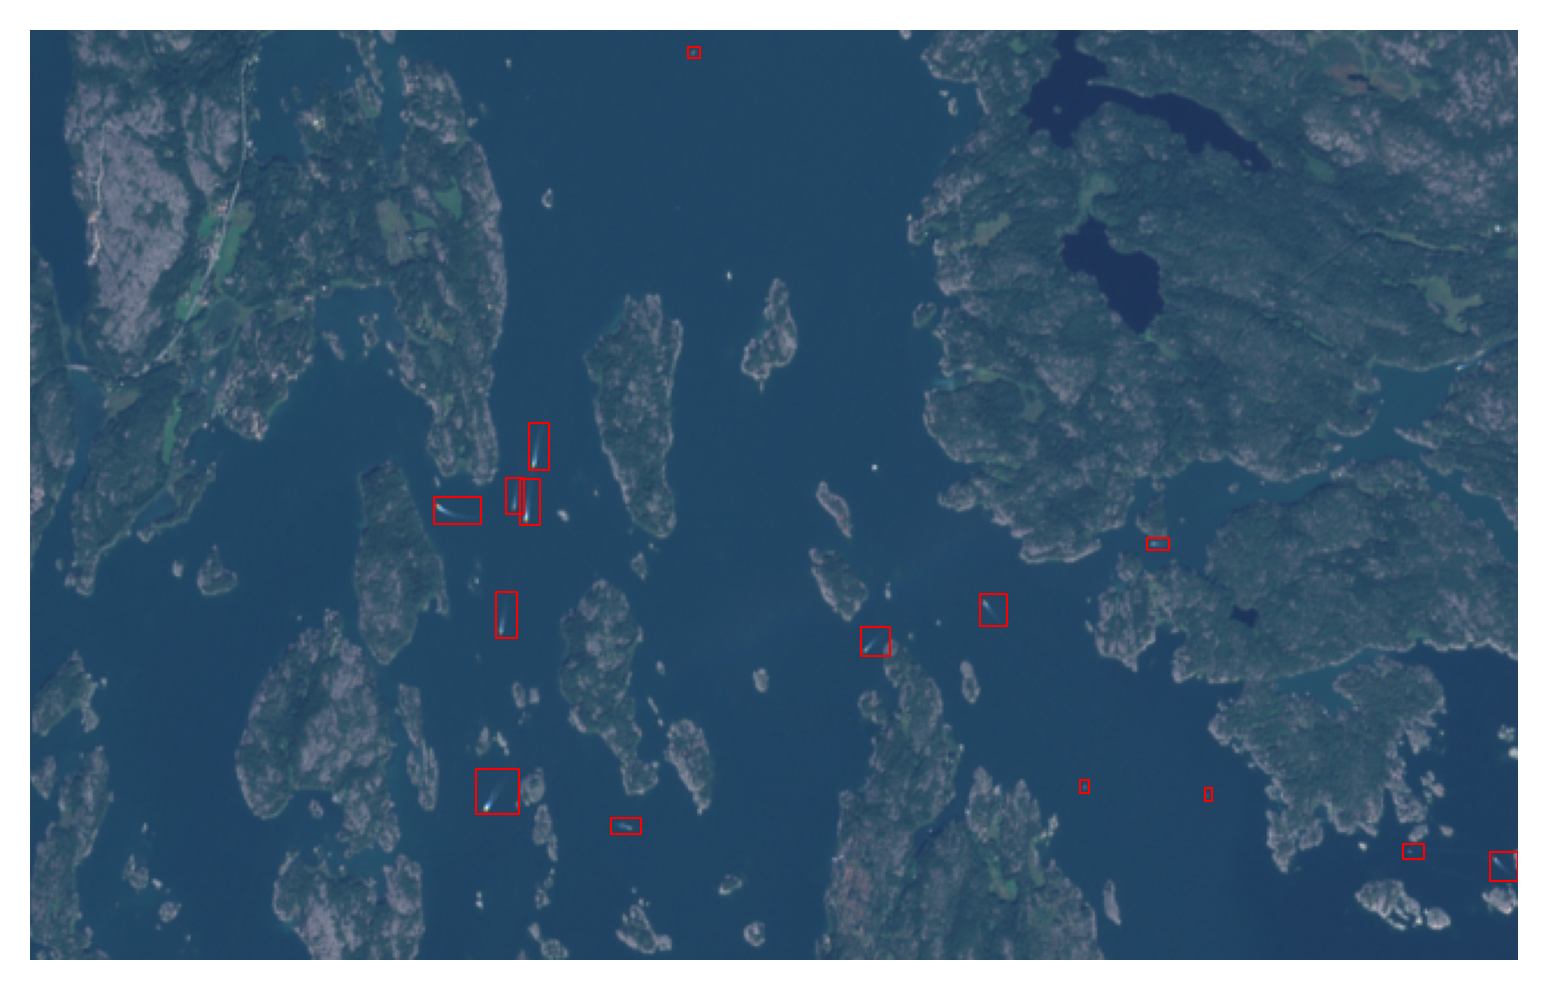

In [100]:
bright = 1.25 # L1C-TCI are dark in the Finnish coast so brighten them
win = Window(8000,5000,640,400)

fig, ax = plt.subplots(1,1, dpi=300)
ax.axis('off')

with rio.open('../dataset/rgb_mosaics/34VEM/S2A_MSIL1C_20220813T095601_N0510_R122_T34VEM_20240717T115958.tif') as src:
    im = src.read(window=win)
    win_transform = src.window_transform(win)
    win_bounds = riowindow.bounds(win, src.transform)
    rioplot.show((im*bright).astype(int), transform=win_transform, ax=ax, adjust=False)
gdf.clip(box(*win_bounds)).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=.5)
plt.show()

### Optional: refining masks with SAM3

While using the original hand-drawn bounding boxes provides satisfactory results, enhancing the boxes with sam3 is suggested. Running [`batch_jobs/create_sam3_masks.sh`](https://github.com/sykefi/marine-vessel-detection/blob/main/batch_jobs/create_sam3_masks.sh) processes all images so that it runs through all bounding boxes, extracts a 140x140 pixel image around it, selects the mask with highest score and runs morphological closing with 1 pixel disk footprint to unify the mask, finally saving the results as polygons.

In [93]:
import sam3
import os
import skimage as ski
from PIL import Image
from geo2ml.data.coordinates import gdf_to_px, georegister_px_df
from rasterio.features import shapes
from shapely import affinity

SAM3_ROOT = os.path.join(os.path.dirname(sam3.__file__))

from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = build_sam3_image_model(bpe_path=f"{SAM3_ROOT}/assets/bpe_simple_vocab_16e6.txt.gz", 
                               device=device,
                               enable_inst_interactivity=True).to(torch.float32)
processor = Sam3Processor(model)

Workflow is the following:

1. Convert annotations to pixel coordinates
2. For each bounding box, extract 140x140 pixel window centered around it as the reference image
3. Run SAM3 with this image with `multimask_output=True`
4. Selet the mask with best score
5. Run `scikit_image.morphology.closing` with `skikit_image.morphology.disk(1)` as the fotprint
6. Convert the results into polygons

Results are instance masks for each annotation, which can then be used as the reference. As polygons have `.bounds` and `.minimum_rotated_rectangle` attributes, mask annotations can be easily used for bounding box or oriented bounding box tasks.

In [96]:
mosaic ='../dataset/rgb_mosaics/34VEM/S2A_MSIL1C_20220813T095601_N0510_R122_T34VEM_20240717T115958.tif'

px_gdf = gdf_to_px(gdf.copy(), mosaic)
px_gdf = px_gdf.clip(box(8000,5000,8640,5400))

with rio.open(mosaic) as src:
    sam_image = np.moveaxis(src.read(), 0, 2)

polys = []
dx = 70
dy = 70

for row in px_gdf.itertuples():
    x = int(row.geometry.centroid.x) # centroid coords
    y = int(row.geometry.centroid.y) # centroid coords
    
    miny = max(0, y-dy)
    maxy = min(10980, y+dy)
    minx = max(0,x-dx)
    maxx = min(10980, x+dx)
    b = row.geometry.exterior.bounds # Bounding box in pixel coordinates
    bbox = np.array([b[0]-minx, b[1]-miny, b[2]-minx, b[3]-miny]) # Scale bounding box
    tempim = sam_image[miny:maxy,minx:maxx] # crop

    with torch.autocast("cuda", dtype=torch.bfloat16):
        inference_state = processor.set_image(Image.fromarray(tempim))

    masks, scores, _ = model.predict_inst(
        inference_state,
        point_coords=None,
        point_labels=None,
        box=bbox[None, :],
        multimask_output=True)
    
    best_ix = np.argmax(scores)
    best_mask = masks[best_ix]
    if masks.sum() == 0: continue

    # 1 pixel closing should fix the gaps
    best_mask = ski.morphology.closing(best_mask, footprint=ski.morphology.disk(1))
    poly = shape(list(shapes(best_mask))[0][0])
    poly = affinity.translate(poly, xoff=minx, yoff=miny)
    polys.append(poly)

poly_gdf = georegister_px_df(
    gpd.GeoDataFrame({'geometry': polys}), 
    mosaic
)

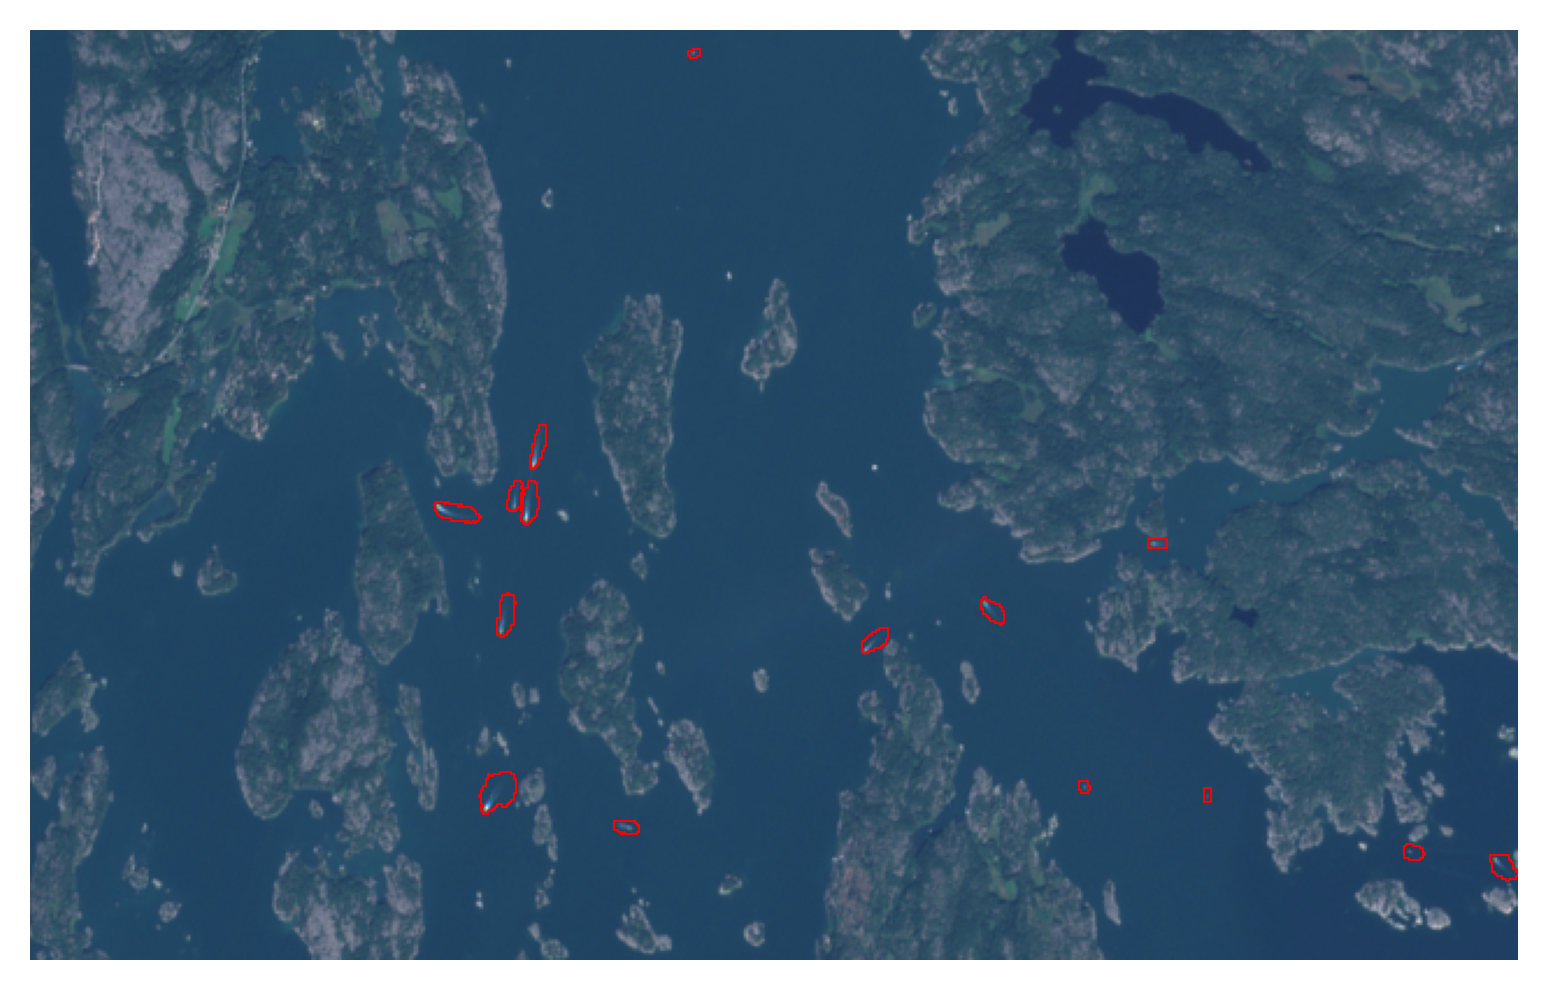

In [99]:
bright = 1.25 # L1C-TCI are dark in the Finnish coast so brighten them
win = Window(8000,5000,640,400)

fig, ax = plt.subplots(1,1, dpi=300)
ax.axis('off')

with rio.open('../dataset/rgb_mosaics/34VEM/S2A_MSIL1C_20220813T095601_N0510_R122_T34VEM_20240717T115958.tif') as src:
    im = src.read(window=win)
    win_transform = src.window_transform(win)
    win_bounds = riowindow.bounds(win, src.transform)
    rioplot.show((im*bright).astype(int), transform=win_transform, ax=ax, adjust=False,
                 percent_range=(2, 98))
poly_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=.5)
plt.show()

## Conversion to `ultralytics`

[`scripts/make_yolo_data.py`](https://github.com/sykefi/marine-vessel-detection/blob/main/scripts/make_yolo_data.py) converts the geopackages and mosaics into `ultralytics` compatible datasets.

Default command for dataset creation is 

```bash
python make_yolo_data.py path_to_annotations path_to_mosaics outpath --tilesize 320 --overlap --n_folds 5
```

The default train-val -split for train tiles is to create a 5x5 grid over each of the tiles, and split this grid into five subsets diagonally. Default option is to use `fold_1` for validation and other data for training. 

For training the models, we used 320x320 image patches with zero overlap, which were then upsampled to 640x640 images by `ultralytics`.  dataset

## torchgeo

The data can also be used with [torchgeo](https://github.com/torchgeo/torchgeo). Install it with `pip install torchgeo`.

In [101]:
import torch
from torch.utils.data import DataLoader
from torchgeo.datasets import Sentinel2, VectorDataset, BoundingBox, stack_samples, random_grid_cell_assignment, IntersectionDataset, GeoDataset
from torchgeo.samplers import *
from torchgeo.datamodules import GeoDataModule
from torchgeo.datamodules.utils import collate_fn_detection

First create dataset for S2

In [102]:
safe_path = Path('../dataset/S2A_MSIL1C_20220813T095601_N0510_R122_T34VEM_20240717T115958.SAFE/')
image_ds = Sentinel2(safe_path)

Then another for annotations

In [120]:
vector_path = Path('../dataset/masks/34VEM.gpkg')
mask_vector_ds = VectorDataset(vector_path, layer='20220813', res=10, task='instance_segmentation')


And then combine datasets

In [121]:
ship_ds_mask = image_ds & mask_vector_ds

Data can be used for semantic segmentation, object_detection and instance segmentation. Change `collate_fn` according to your needs.

In [131]:
size = 320
train_sampler_mask = RandomGeoSampler(ship_ds_mask, size=size, length=1000)
train_dataloader = DataLoader(
    ship_ds_mask, batch_size=2, sampler=train_sampler_mask, collate_fn=collate_fn_detection
)

sample = next(iter(train_dataloader))
sample.keys()

dict_keys(['image', 'bbox_xyxy', 'label', 'mask'])

Visualize the outputs 

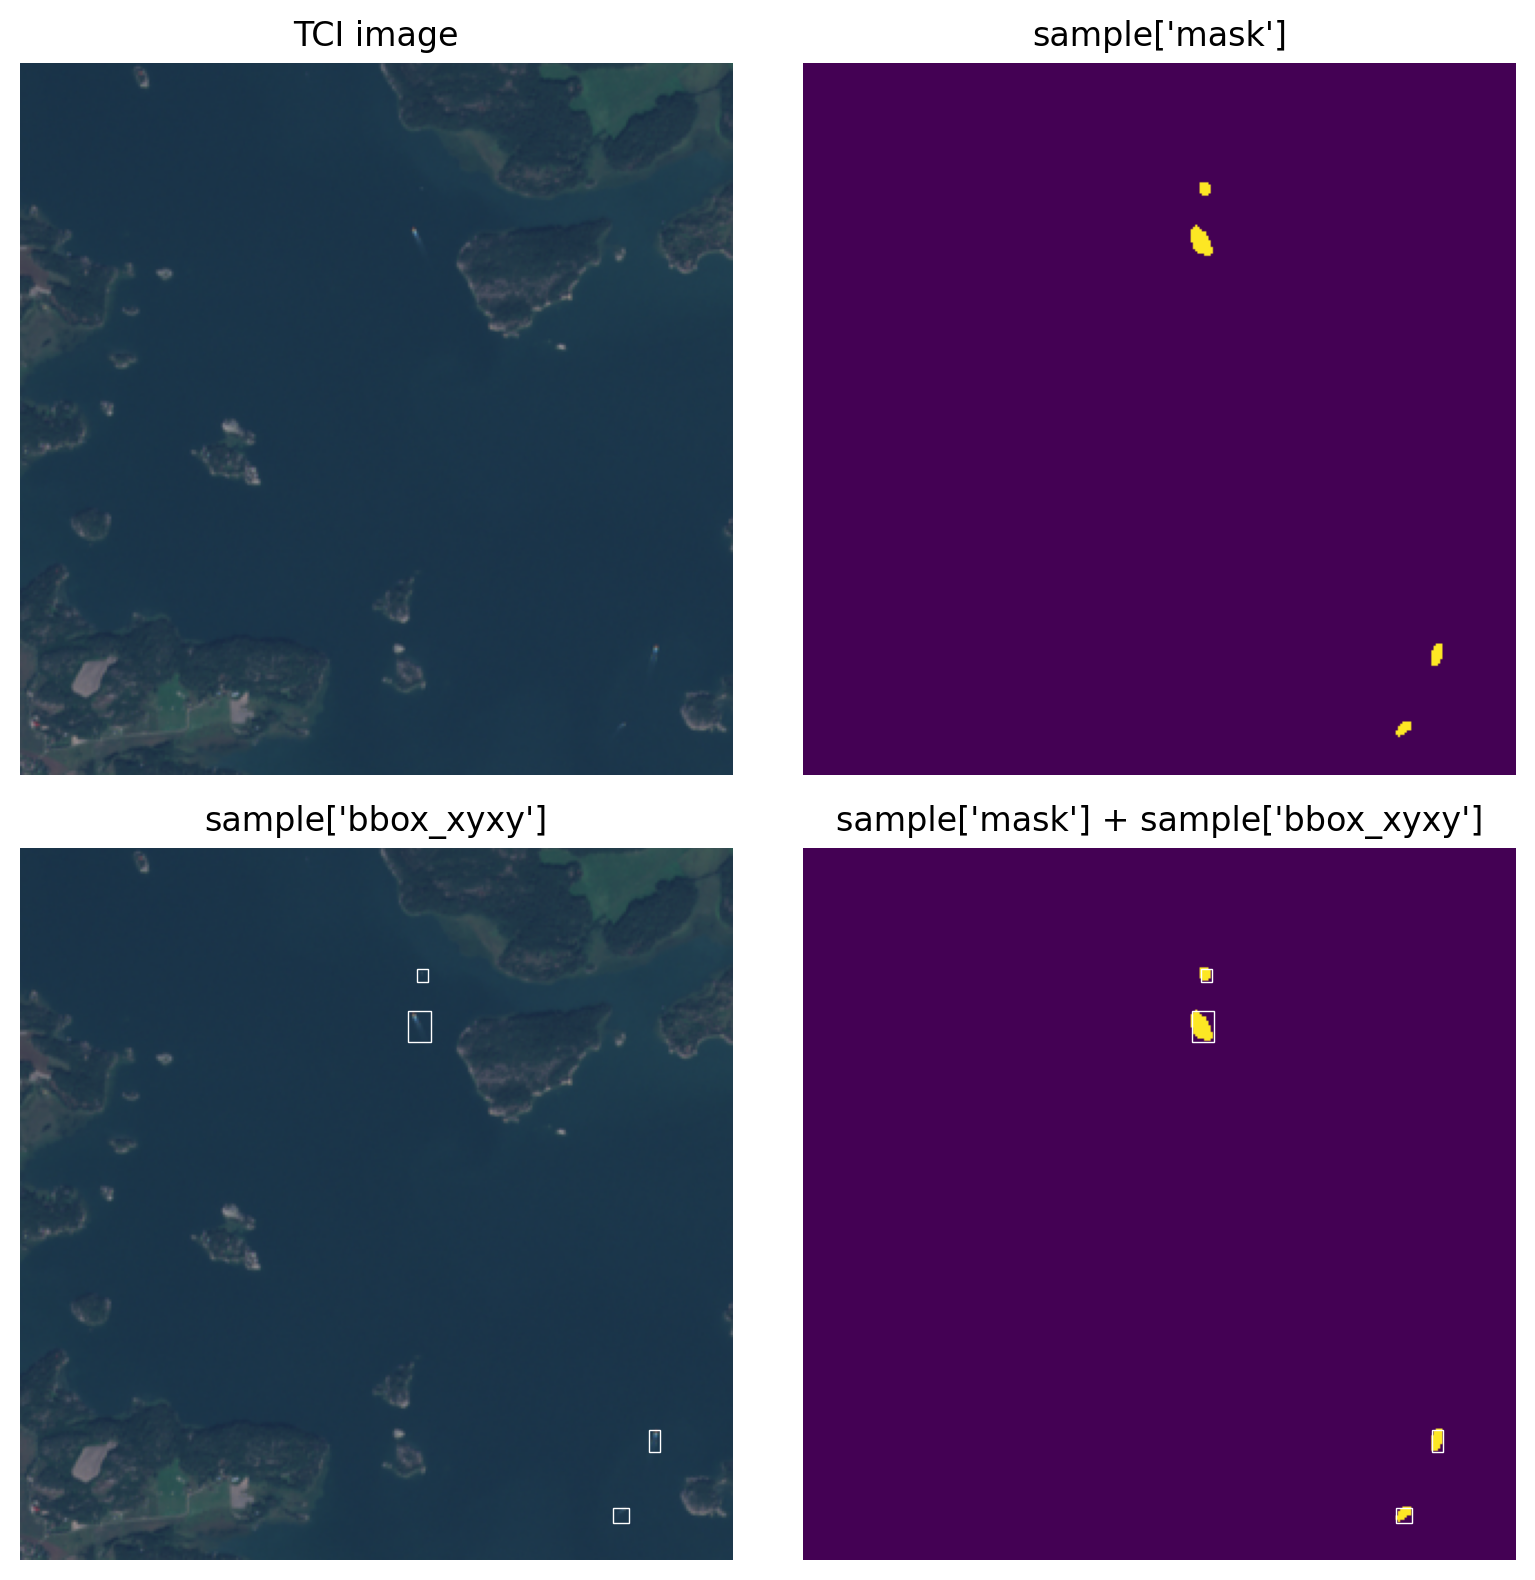

In [135]:
import matplotlib.patches as mpatches

ix = 1

f, axs = plt.subplots(2,2, dpi=200, figsize=(8,8))
for a in axs.flatten(): a.axis('off')
tci_img = (np.clip((((sample['image'][ix][1:4].permute(1,2,0)-1000))/3558.),0,1)*255*1.25).to(int)
tci_img = np.dstack([tci_img[:,:,2], tci_img[:,:,1], tci_img[:,:,0]]) 
fullmask = sample['mask'][ix].sum(axis=(0))
axs[0,0].imshow(tci_img)
axs[0,1].imshow(fullmask)
axs[1,0].imshow(tci_img)
axs[1,1].imshow(fullmask)

boxes = sample['bbox_xyxy'][ix]
for bbox in boxes:
    axs[1,0].add_patch(
        mpatches.Rectangle(
            (bbox[0], bbox[1]),
            bbox[2]-bbox[0],
            bbox[3]-bbox[1],
            fill=False,
            color='white',
            linewidth=.5
        )
    )

    axs[1,1].add_patch(
        mpatches.Rectangle(
            (bbox[0], bbox[1]),
            bbox[2]-bbox[0],
            bbox[3]-bbox[1],
            fill=False,
            color='white',
            linewidth=.5
        )
    )
    

axs[0,0].set_title('TCI image')
axs[0,1].set_title("sample['mask']")
axs[1,0].set_title("sample['bbox_xyxy']")
axs[1,1].set_title("sample['mask'] + sample['bbox_xyxy']")
plt.tight_layout()

plt.show()